# Project

## Loading the dataset

In [ ]:
import glob
import polars as pl
import os

In [2]:
DATA_ROOT = "data"

In [ ]:
def get_labels_from_filename(filename):
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False

In [ ]:
def combine_dataset_files(root, save_name="combined_dataset"):
    path = os.path.join(root, "*", "*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [5]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_ROOT, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_ROOT, save_name)
    df = pl.read_parquet(path)
    return df

In [6]:
df = load_dataset("combined_dataset").with_columns(
    pl.col(pl.Float64).cast(pl.Float32)
)  # reducing memory usage

## Exploratory Data Analysis

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [8]:
def plot_attack_counts(data):
    attack_counts = data.group_by("Name").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Name", y="len", data=attack_counts, ax=ax)
    ax.set_title("Distribution of Attack Names (Entire Dataset)")
    ax.set_xlabel("Attack Name")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_405534/4110133150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


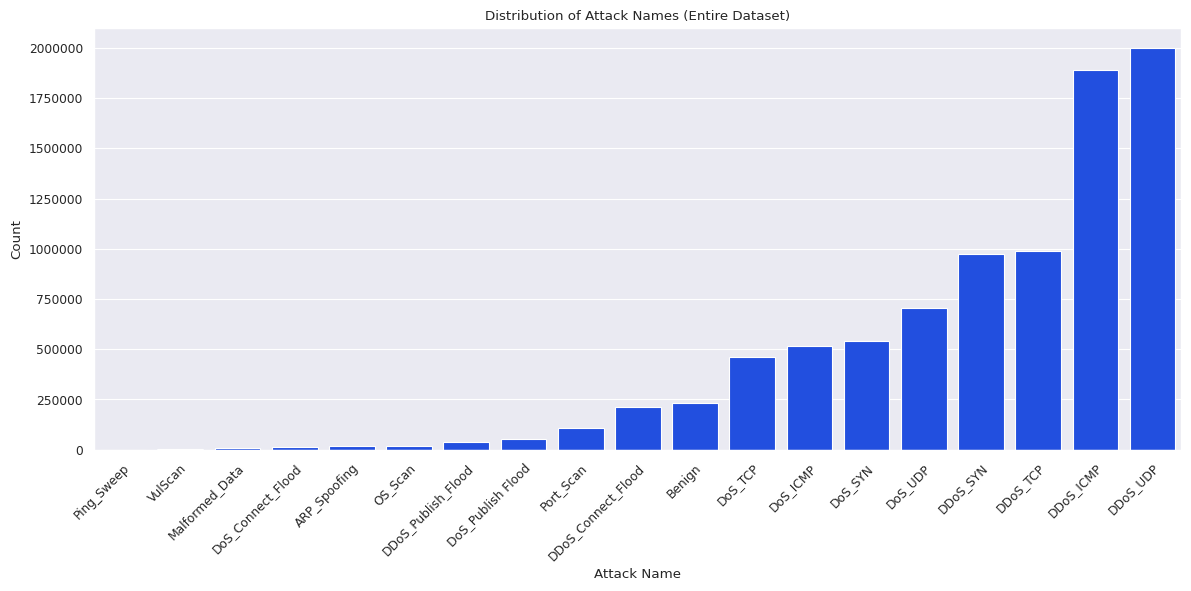

In [9]:
plot_attack_counts(df)

In [10]:
def plot_ddos_dos_bar(data):
    ddos_dos_counts = (
        data.filter(pl.col("Category").is_in(["DDoS", "DoS"]))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    data = ddos_dos_counts.to_pandas()
    data.columns = ["Attack Type", "Count"]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Attack Type", y="Count", data=data, ax=ax)
    ax.set_title("Distribution of DDoS and DoS Attacks (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_405534/4247166012.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


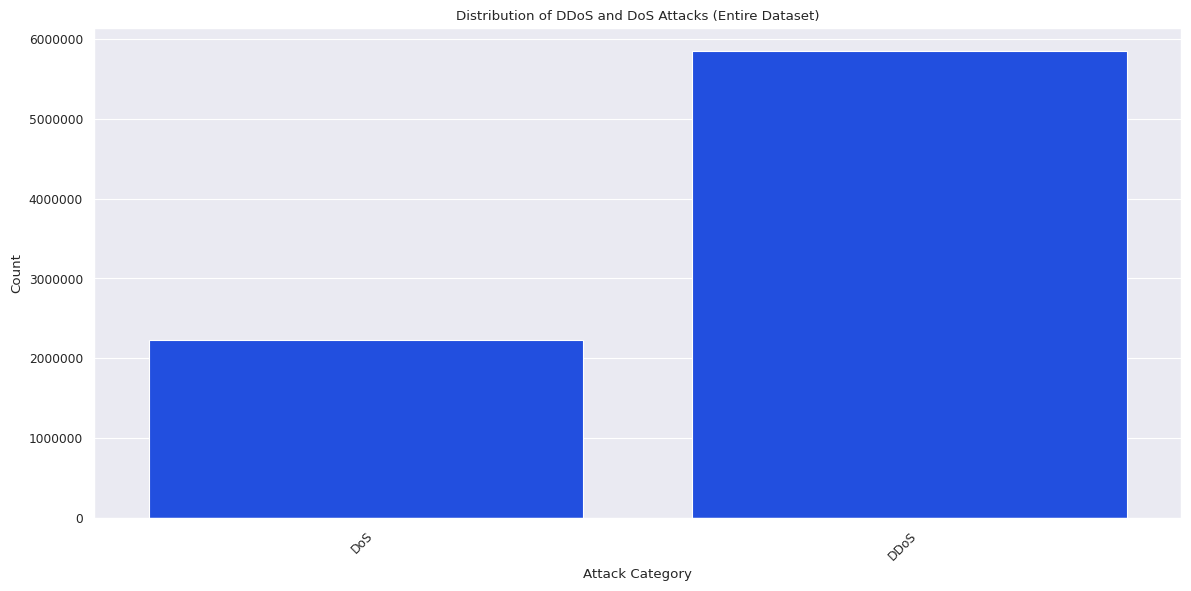

In [11]:
plot_ddos_dos_bar(df)

In [12]:
def plot_categories_no_ddos_dos(data):
    included_categories = ["MQTT", "Spoofing", "Recon", "Benign"]
    data = (
        data.filter(pl.col("Category").is_in(included_categories))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    ).to_pandas()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title(
        "Distribution of Attack Categories (Excluding DDoS and DoS) (Entire Dataset)"
    )
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_405534/2544595696.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


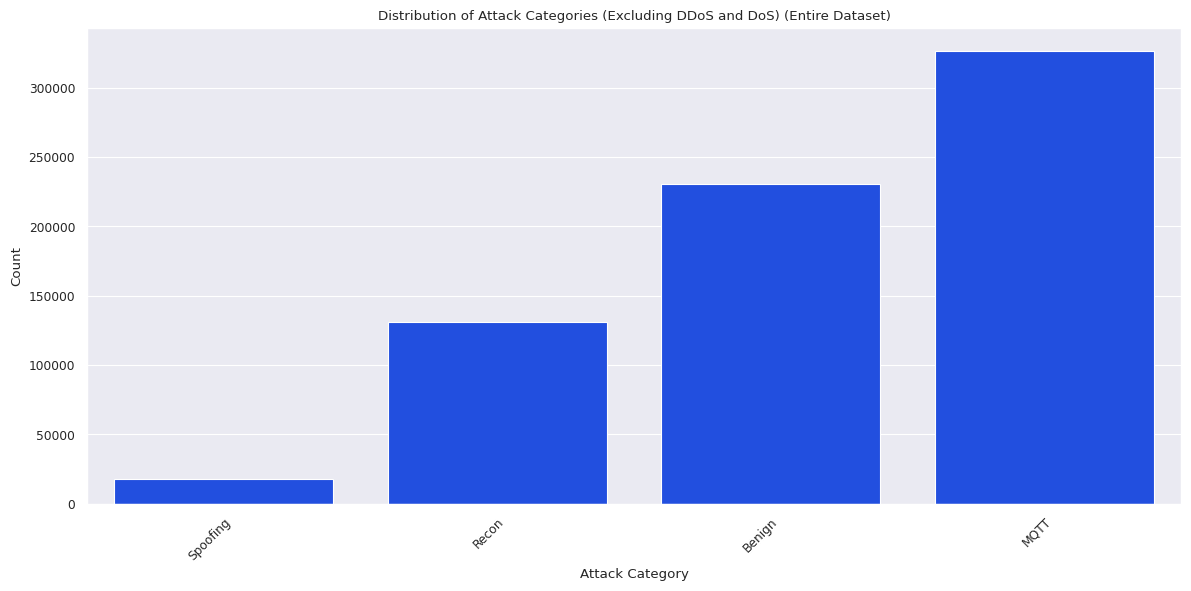

In [13]:
plot_categories_no_ddos_dos(df)

In [14]:
def plot_all_attack_categories_bar(data):
    data = data.group_by("Category").len().sort("len", descending=False).to_pandas()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_405534/3849087223.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


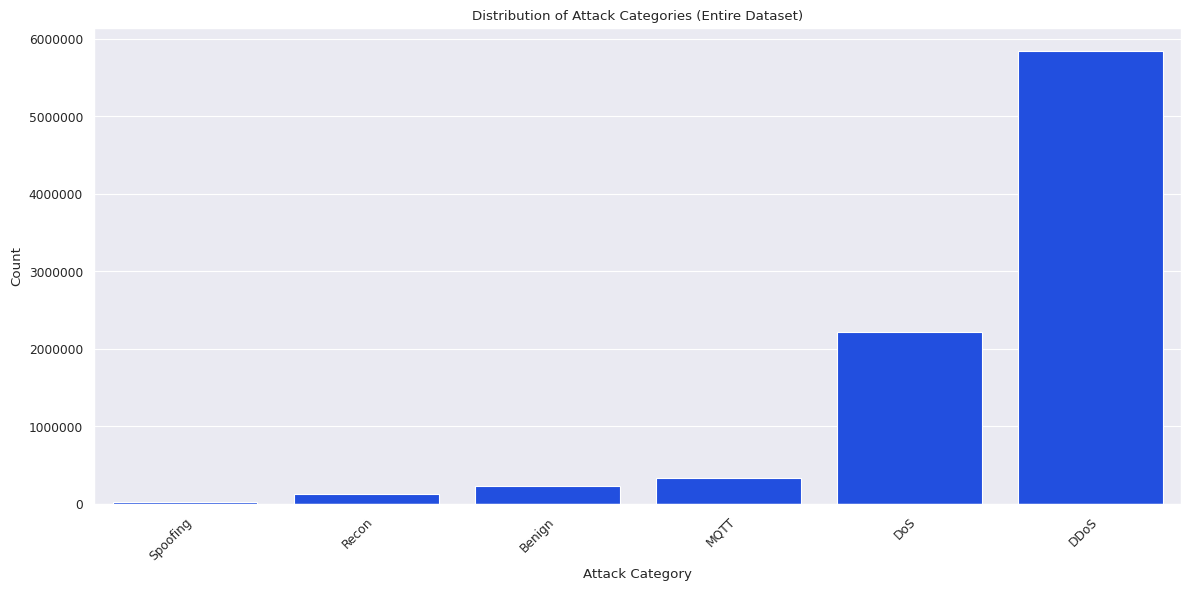

In [15]:
plot_all_attack_categories_bar(df)

In [16]:
def plot_attack_benign_pie(data):
    attack_counts = data.group_by("Attack").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = ["Attack", "Count"]

    attack_counts = attack_counts.set_index("Attack")["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    colours = sns.color_palette("hls", len(labels))

    fig, ax = plt.subplots()
    ax.set_title("Comparison between Benign and Attack Data (Entire Dataset)")
    plt.pie(
        slices,
        colors=colours,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)" for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title="Malicious Traffic?",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

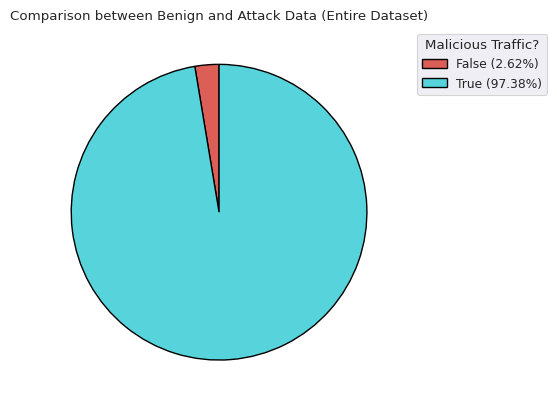

In [17]:
plot_attack_benign_pie(df)

In [18]:
def plot_correlation_heatmap(data):
    numeric_data = data.select(
        pl.exclude("Attack", "Category", "Name").name.map(lambda name: name.lower())
    )

    std_devs = numeric_data.select(pl.all().std())
    zer_var_cols = [col for col in std_devs.columns if std_devs[col][0] == 0]
    numeric_data = numeric_data.drop(zer_var_cols)

    corr = numeric_data.corr()
    corr_labels = corr.columns
    corr = corr.to_numpy()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(15, len(corr_labels) // 2))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        square=True,
        ax=ax,
        mask=mask,
        cbar_kws={"label": "Correlation Coefficient", "shrink": 0.5, "aspect": 30},
        xticklabels=corr_labels,
        yticklabels=corr_labels,
    )

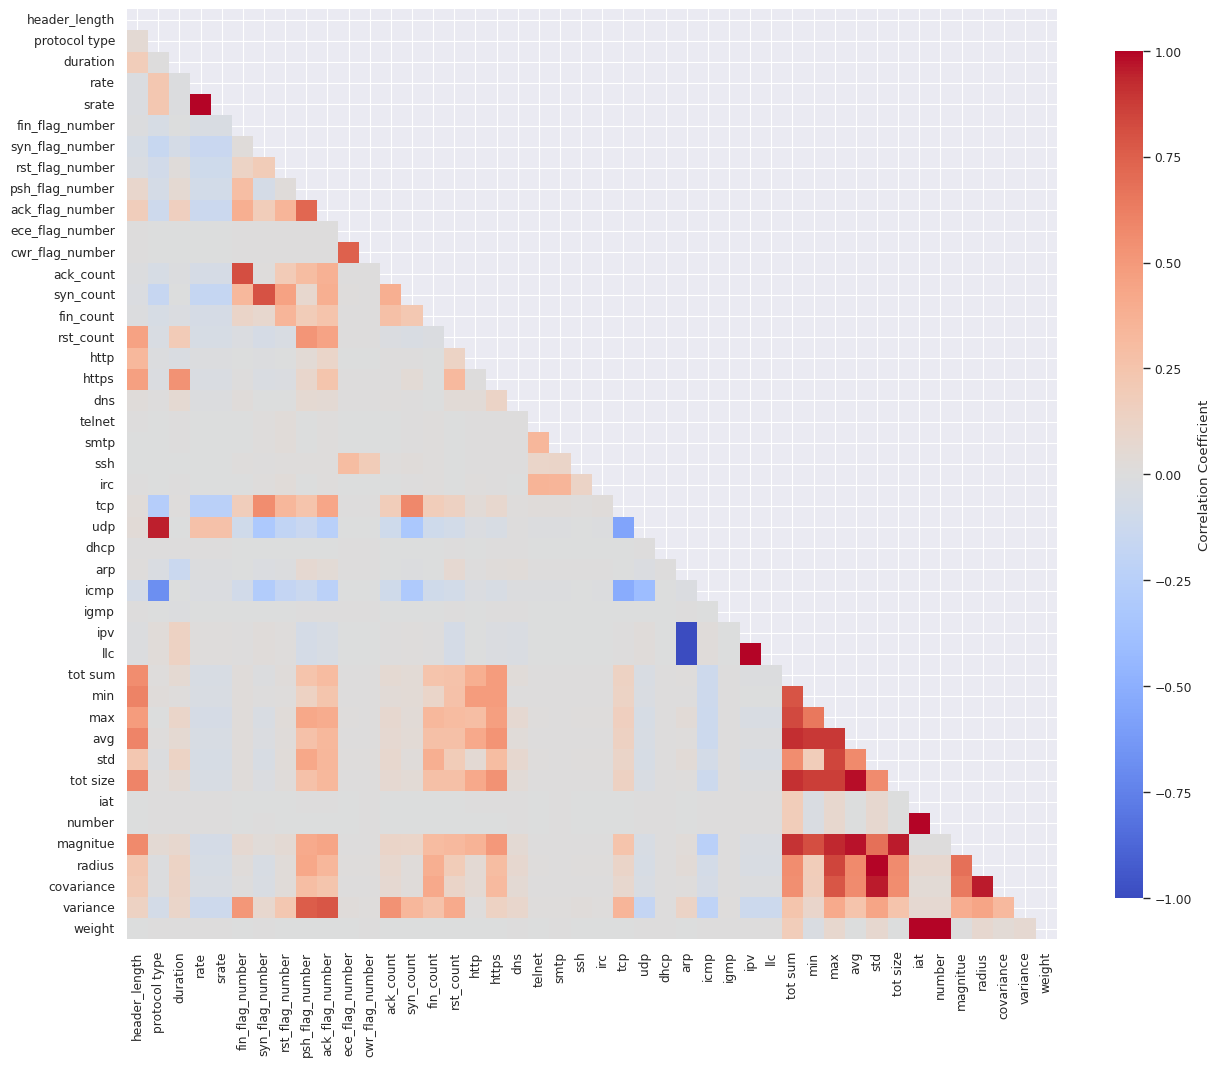

In [19]:
plot_correlation_heatmap(df)

## Preprocessing

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
df = df.to_pandas()
df = df[df["Category"] != "Spoofing"].copy()  # Discarding spoofing data
df = df.reset_index(drop=True)

In [22]:
X = df.drop(columns=["Name", "Attack", "Category"])
y = df["Category"]
del df

### Splitting Data into Subsets

In [23]:
train_percent = 0.8
val_percent = 0.1
test_percent = 0.1

In [24]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_percent, random_state=42, stratify=y
)

val_adjusted_size = val_percent / (train_percent + val_percent)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_adjusted_size,
    random_state=42,
    stratify=y_train_val,
)

In [25]:
del X_train_val, y_train_val

In [26]:
print(f"Train {len(X_train)/len(X):.0%} ({len(X_train)} rows)")
print(f"Validation {len(X_val)/len(X):.0%} ({len(X_val)} rows)")
print(f"Test {len(X_test)/len(X):.0%} ({len(X_test)} rows)")

Train 80% (7005776 rows)
Validation 10% (875723 rows)
Test 10% (875723 rows)


### Sampling Techniques

In [27]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [28]:
def plot_breakdown_pie(data, title):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    ax.set_title(title)
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)" for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

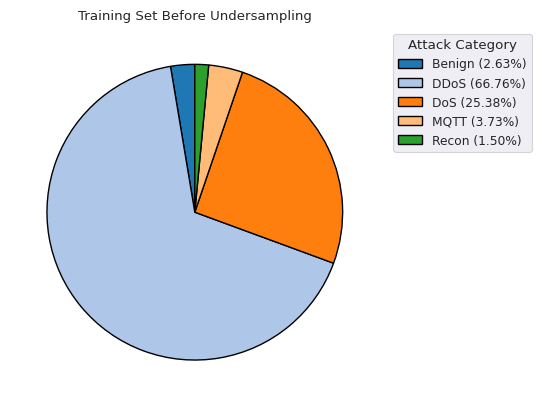

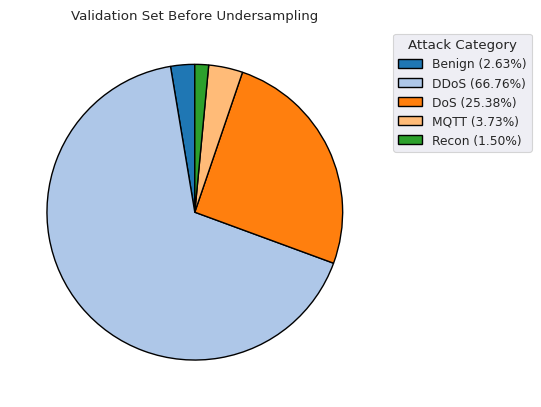

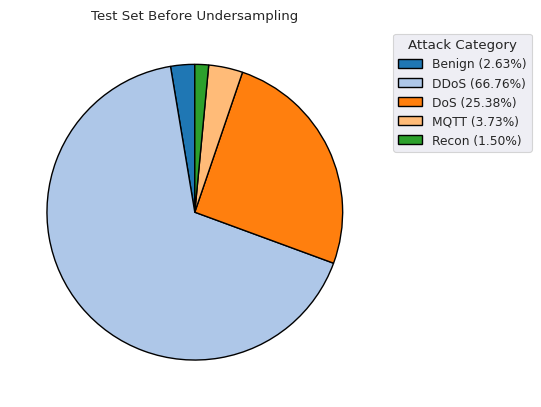

In [29]:
plot_breakdown_pie(
    pl.DataFrame({"Category": y_train}), "Training Set Before Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_val}), "Validation Set Before Undersampling"
)
plot_breakdown_pie(pl.DataFrame({"Category": y_test}), "Test Set Before Undersampling")

In [30]:
undersample_strategy = {
    "DDoS": 2_500_000,
}
oversample_strategy = {
    "Benign": 1_200_000,
    "MQTT": 800_000,
    "Recon": 600_000,
}

In [31]:
pipeline = Pipeline(
    steps=[
        ("over", SMOTE(sampling_strategy=oversample_strategy, random_state=42)),
        ("under", RandomUnderSampler(sampling_strategy=undersample_strategy)),
    ]
)

In [32]:
X_train, y_train = pipeline.fit_resample(X_train, y_train)

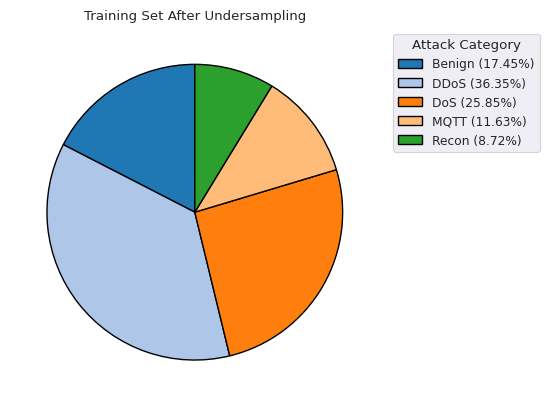

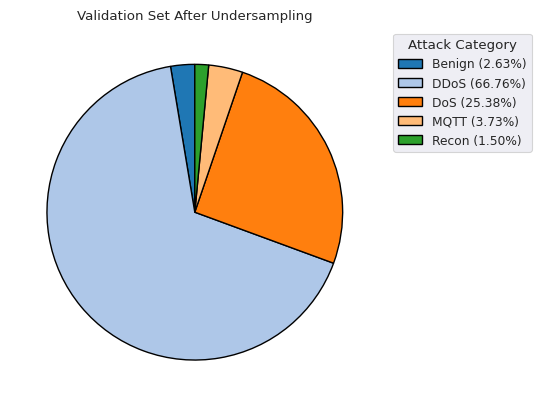

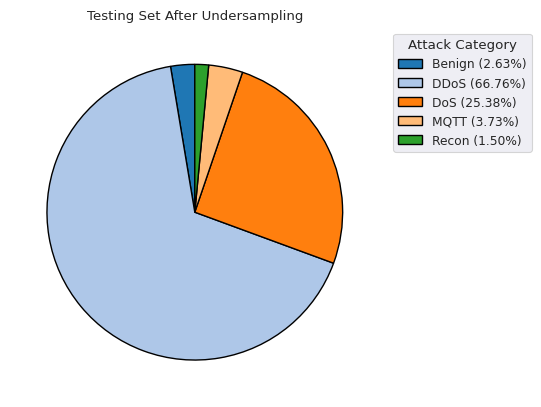

In [33]:
plot_breakdown_pie(
    pl.DataFrame({"Category": y_train}), "Training Set After Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_val}), "Validation Set After Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_test}), "Testing Set After Undersampling"
)

### Scaling and Labelling Data

In [34]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [35]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
y_test = encoder.transform(y_test)

In [36]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
del X_train, X_val, df, X

In [38]:
print(f"Training shape: {X_train_scaled.shape[0]} rows")
print(f"Validation shape: {X_val_scaled.shape[0]} rows")
print(f"Testing shape: {X_test_scaled.shape[0]} rows")

Training shape: 6877763 rows
Validation shape: 875723 rows
Testing shape: 875723 rows


## Model Design

In [39]:
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

2026-03-11 14:24:29.487889: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 14:24:30.098512: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 14:24:32.092956: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [40]:
def build_dnn(input_dimensions, output_dimension=5):
    model = Sequential(
        [
            Input(shape=(input_dimensions[1],)),
            Dense(256, activation="relu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation="relu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation="relu", kernel_regularizer=l2(1e-5)),
            Dense(output_dimension, activation="softmax"),
        ]
    )

    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [41]:
model = build_dnn(X_train_scaled.shape, 5)
model.summary()

2026-03-11 14:24:32.709429: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,789 (214.02 KB)

 Trainable params: 54,021 (211.02 KB)

 Non-trainable params: 768 (3.00 KB)

## Model Training

In [ ]:
from sklearn.utils import class_weight
import pandas as pd

In [ ]:
classes = np.unique(y_train)
weights = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [43]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=75,
    batch_size=2048,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-5),
    ],
    class_weight=class_weights,
)

Epoch 1/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - accuracy: 0.7589 - loss: 0.3142 - val_accuracy: 0.6826 - val_loss: 0.5513 - learning_rate: 3.0000e-04
Epoch 2/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 67s 20ms/step - accuracy: 0.7838 - loss: 0.2727 - val_accuracy: 0.6887 - val_loss: 0.5450 - learning_rate: 3.0000e-04
Epoch 3/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 67s 20ms/step - accuracy: 0.7869 - loss: 0.2653 - val_accuracy: 0.7181 - val_loss: 0.5159 - learning_rate: 3.0000e-04
Epoch 4/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.7889 - loss: 0.2610 - val_accuracy: 0.7254 - val_loss: 0.5008 - learning_rate: 3.0000e-04
Epoch 5/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.7920 - loss: 0.2567 - val_accuracy: 0.7229 - val_loss: 0.5064 - learning_rate: 3.0000e-04
Epoch 6/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.7940 - loss: 0.2542 - val_accuracy: 0.7240 - val_loss: 0.5056 - learning_rate: 3.0000e-04
Epoch 7/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
folder_name = "models"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created folder: {folder_name}")

model_path = os.path.join(folder_name, "model.keras")
model.save(model_path)
history_path = os.path.join(folder_name, "history.csv")
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(history_path, index = False)

print(f"Saved model to {model_path} and saved history to {history_path}")

Saved model to models/model.keras and saved history to models/history.csv


## Model Evaluation

In [13]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [ ]:
model = load_model("models/model.keras")
history = pd.read_csv("models/history.csv")

_, X_test, _, y_test = train_test_split(
    X, y, test_size=test_percent, random_state=42, stratify=y
)

In [15]:
def plot_accuracy_and_loss(history):

    train_loss = history["loss"]
    val_loss = history["val_loss"]
    train_acc = history["accuracy"]
    val_acc = history["val_accuracy"]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy
    ax[0].plot(train_acc, label="Training Accuracy")
    ax[0].plot(val_acc, label="Validation Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    # Loss
    ax[1].plot(train_loss, label="Training Loss")
    ax[1].plot(val_loss, label="Validation Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.show()

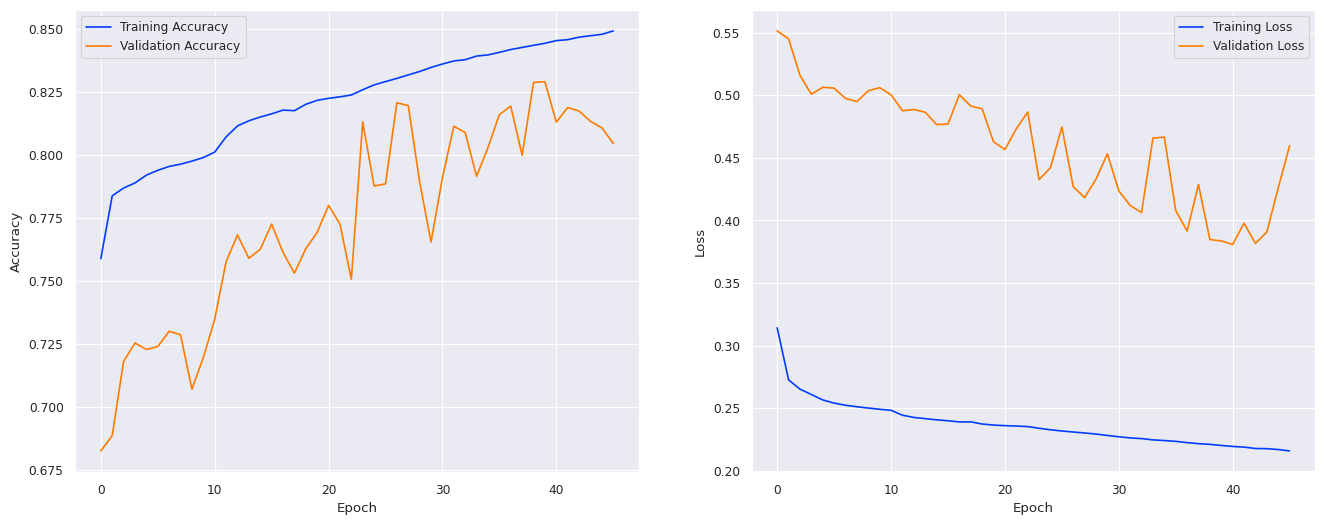

In [16]:
plot_accuracy_and_loss(history)

In [17]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax[0],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[0].set_title("Confusion Matrix (Counts)")
    ax[0].set_ylabel("True Label")
    ax[0].set_xlabel("Predicted Label")

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        ax=ax[1],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[1].set_title("Confusion Matrix (Normalized)")
    ax[1].set_ylabel("True Label")
    ax[1].set_xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [18]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

NameError: name 'X_test_scaled' is not defined

[[ 22645      1      0    143    245]
 [     4 520908  63744      5      2]
 [     4  97425 124780      8      4]
 [   254      0      3  32386     22]
 [   525      1      1     11  12602]]


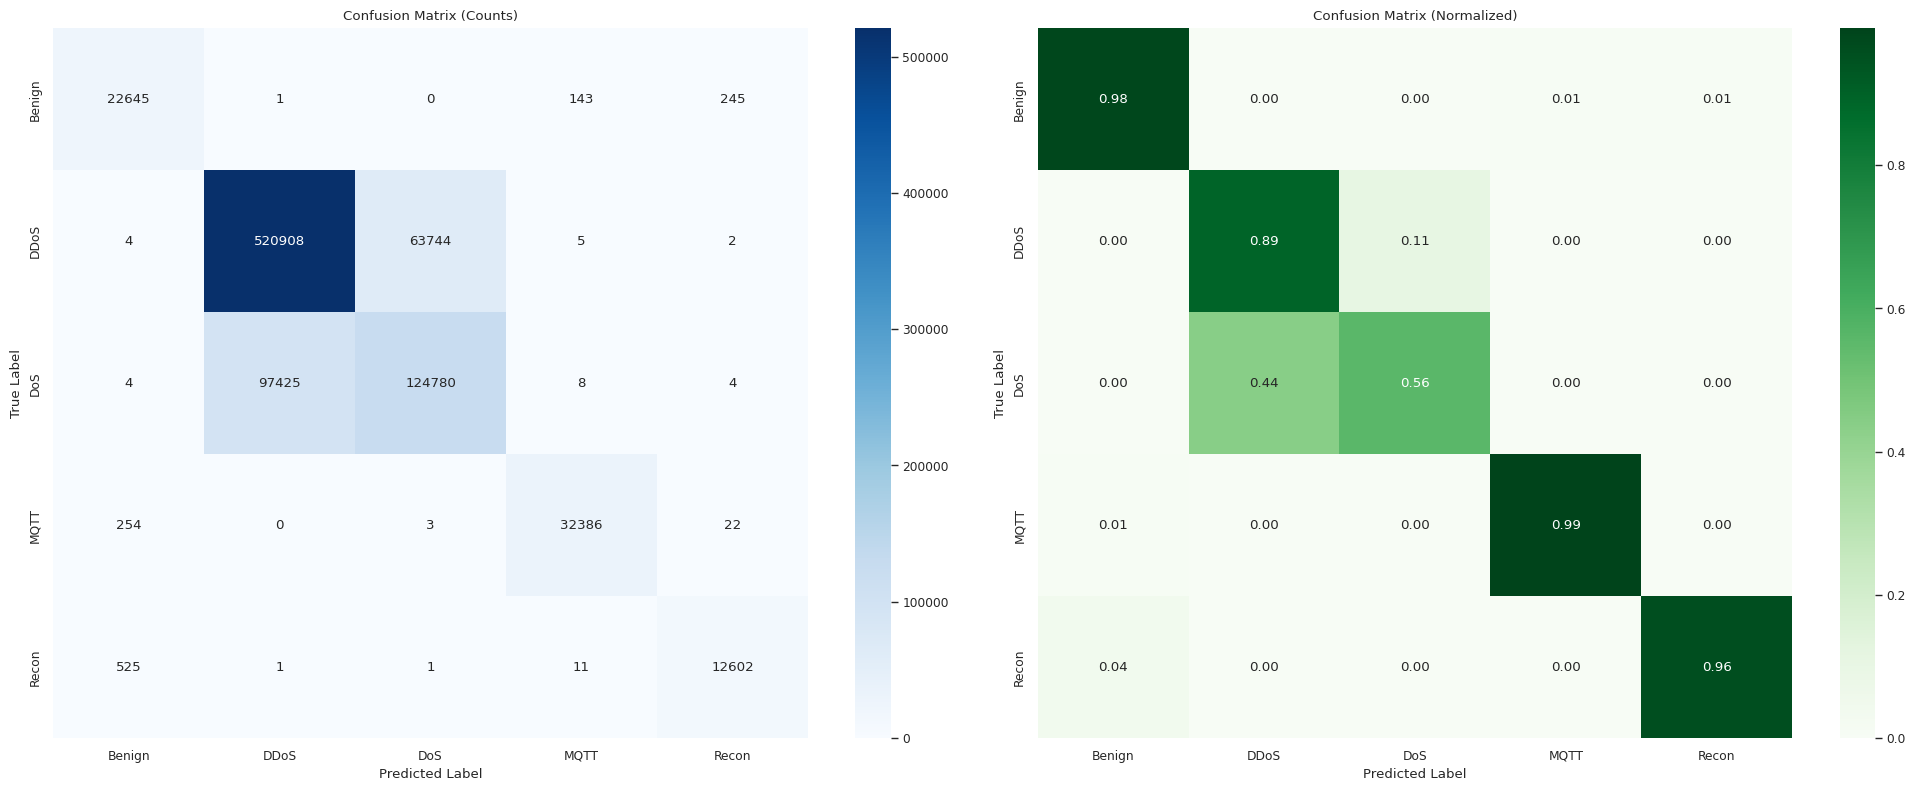

In [ ]:
plot_confusion_matrix(y_test, y_pred_classes, encoder.classes_)

In [ ]:
print(
    classification_report(
        y_test, y_pred_classes, digits=4, target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Benign     0.9664    0.9831    0.9747     23034
        DDoS     0.8424    0.8910    0.8660    584663
         DoS     0.6619    0.5615    0.6076    222221
        MQTT     0.9949    0.9915    0.9932     32665
       Recon     0.9788    0.9591    0.9688     13140

    accuracy                         0.8146    875723
   macro avg     0.8889    0.8772    0.8821    875723
weighted avg     0.8076    0.8146    0.8096    875723



In [ ]:
f1_score(y_test, y_pred_classes, average="macro")

0.8820535287497056

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 21s 749us/step - accuracy: 0.8146 - loss: 0.3795
Test accuracy: 0.8146


## Explainability

In [ ]:
import shap
shap.initjs()

In [ ]:
explainer = shap.KernelExplainer(model.predict, X_train_scaled[:100])
shap_values = explainer.shap_values(X_test_scaled[:100])

shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

In [ ]:
X_train_scaled.columns

In [ ]:
_, X_sample_unscaled, _, y_sample = train_test_split(
    X_test, y_test, test_size=500, stratify=y_test, random_state=42
)
_, X_sample_scaled, _, y_sample = train_test_split(
    X_test_scaled, y_test, test_size=500, stratify=y_test, random_state=42
)
X_sample_array = X_sample_scaled.values

In [ ]:
del X_test

In [ ]:
background = shap.sample(X_train_scaled, 500)
class_labels = encoder.classes_

### SHAP

In [ ]:
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_sample_array)

In [ ]:
print(f"Model output shape: {model.output_shape}")
print(f"Number of SHAP arrays: {len(shap_values)}")
print(f"Number of labels: {len(encoder.classes_)}")

In [ ]:
for i, class_name in enumerate(encoder.classes_):
    mean_abs = np.abs(shap_values[:, :, i]).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-10:]
    top_idx = top_idx[np.argsort(mean_abs[top_idx])]
    plt.figure()
    plt.barh(
        X_sample_scaled.columns[top_idx],
        mean_abs[top_idx]
    )
    
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top 10 Feature Importance for Class: {class_name}")
    plt.show()